# 05 — Monte Carlo Simulation

For each period, this notebook generates **1,000 synthetic daily demand profiles**. Each run uses the fitted temporal model plus a bootstrapped **complete historical residual-day vector**, rather than 24 independent random errors.

### What to look for
- Simulated daily means, peaks, and variability should remain in plausible historical ranges.
- Peak-hour behavior should resemble the corresponding historical period.
- The simulation should produce complete 24-hour profiles with no negative demand values.

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src" / "data_preparation.py").is_file():
    project_root = project_root.parent
if not (project_root / "src" / "data_preparation.py").is_file():
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PERIOD_ORDER
figures_dir = project_root / "figures"
results_dir = project_root / "results"
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

from src.modeling import fit_period_model
from src.simulation import simulate_days, simulation_daily_summary

df = pd.read_csv(project_root / "data/processed/luzon_hourly_clean.csv", parse_dates=["date", "datetime"])
bundles = {p: fit_period_model(df, p) for p in PERIOD_ORDER}

simulations = {}
summaries = []
for i, period in enumerate(PERIOD_ORDER):
    b = bundles[period]
    sim = simulate_days(b.model, b.residual_library, b.train, n_runs=1000, seed=42+i, period=period)
    simulations[period] = sim
    summaries.append(simulation_daily_summary(sim))
sim_summary = pd.concat(summaries, ignore_index=True)
print(f"Generated {sim_summary.shape[0]:,} synthetic days ({len(PERIOD_ORDER)} × 1,000).")

Generated 3,000 synthetic days (3 × 1,000).


In [3]:
def q05(x): return x.quantile(0.05)
def q95(x): return x.quantile(0.95)
summary_table = (
    sim_summary.groupby("period", observed=True)
    .agg(
        mean_daily_demand_MW=("mean_demand_mw", "mean"),
        p05_daily_demand_MW=("mean_demand_mw", q05),
        p95_daily_demand_MW=("mean_demand_mw", q95),
        mean_daily_peak_MW=("max_demand_mw", "mean"),
        p05_peak_MW=("max_demand_mw", q05),
        p95_peak_MW=("max_demand_mw", q95),
        mean_within_day_SD_MW=("std_demand_mw", "mean"),
    )
    .reindex(PERIOD_ORDER)
)
modal_peak = sim_summary.groupby("period", observed=True)["peak_hour"].agg(lambda s: int(s.mode().iloc[0]) + 1)
summary_table["modal_NGCP_Hour_No"] = modal_peak
summary_table.round(2)

,mean_daily_demand_MW,p05_daily_demand_MW,p95_daily_demand_MW,mean_daily_peak_MW,p05_peak_MW,p95_peak_MW,mean_within_day_SD_MW,modal_NGCP_Hour_No
period,,,,,,,,
Pre-pandemic,7747.73,6462.46,9059.91,8977.53,7340.85,10525.00,958.51,14
Pandemic,8020.65,6528.96,9383.21,9169.19,7303.00,10802.45,836.62,14
Recovery,9130.85,7569.92,10613.10,10435.72,8477.85,12256.95,981.57,14


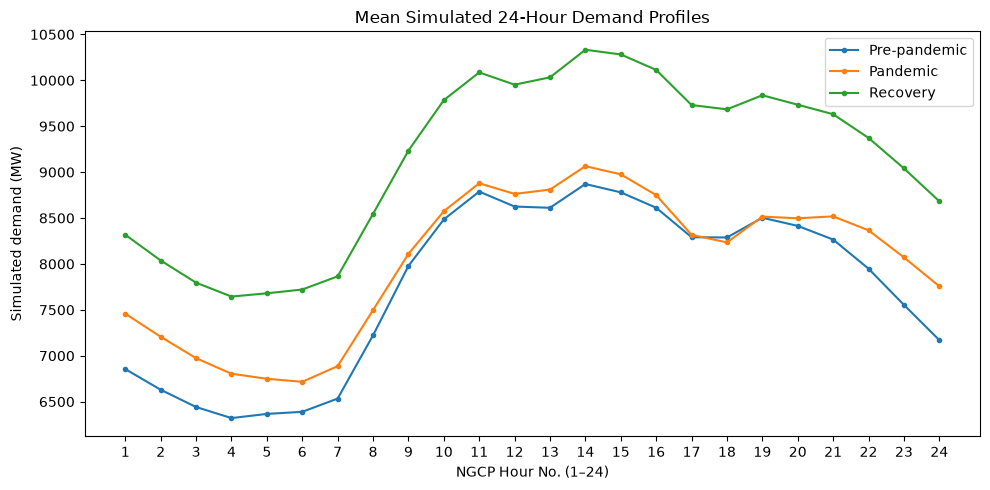

In [4]:
plt.figure(figsize=(10, 5))
for period in PERIOD_ORDER:
    sim = simulations[period]
    profile = sim.groupby("hour")["demand_mw"].mean()
    plt.plot(profile.index + 1, profile.values, marker="o", markersize=3, label=period)
plt.title("Mean Simulated 24-Hour Demand Profiles")
plt.xlabel("NGCP Hour No. (1–24)")
plt.ylabel("Simulated demand (MW)")
plt.xticks(range(1, 25))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "simulation_mean_profiles.png", dpi=160)
plt.show()

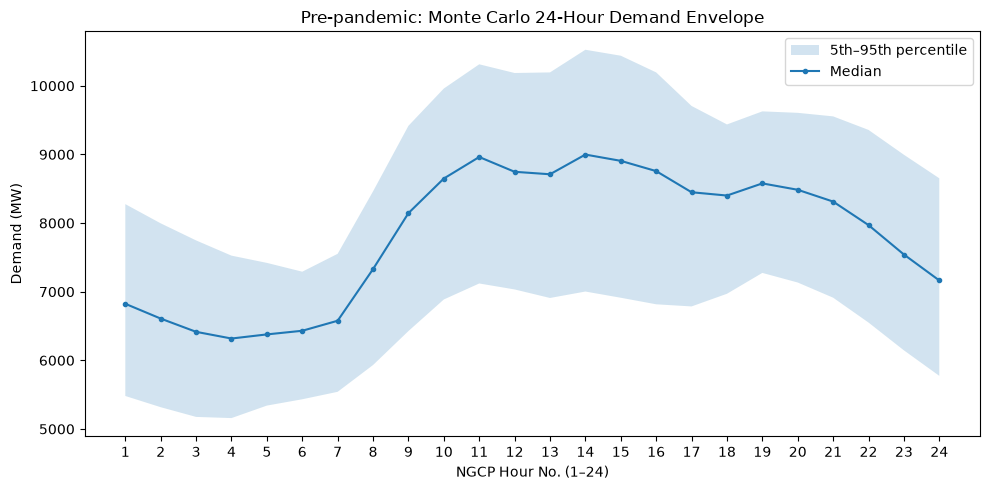

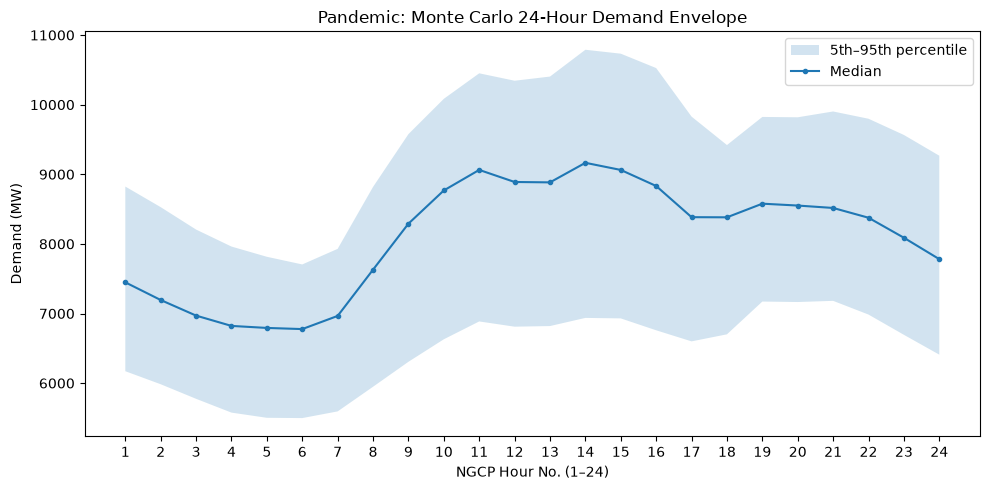

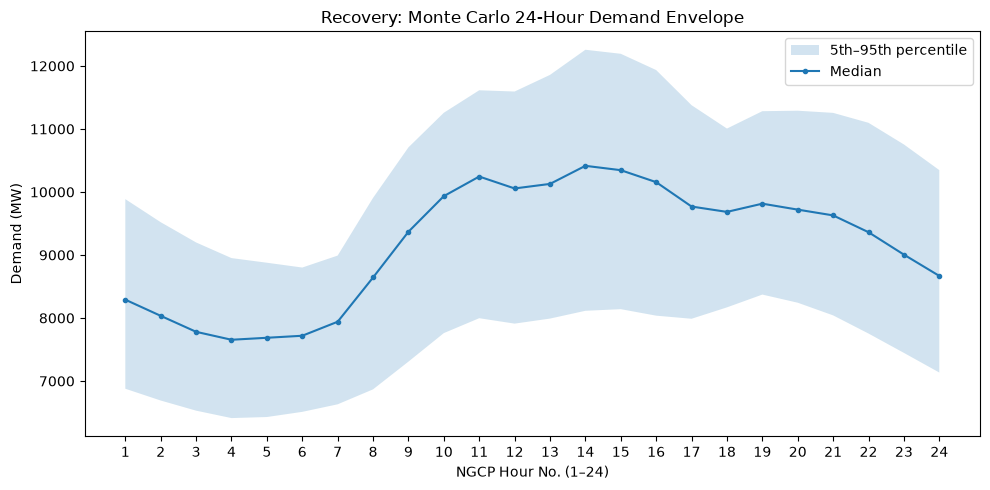

In [5]:
for period in PERIOD_ORDER:
    sim = simulations[period]
    q = sim.groupby("hour")["demand_mw"].quantile([0.05, 0.50, 0.95]).unstack()
    x = q.index.to_numpy() + 1
    plt.figure(figsize=(10, 5))
    plt.fill_between(x, q[0.05].to_numpy(), q[0.95].to_numpy(), alpha=0.2, label="5th–95th percentile")
    plt.plot(x, q[0.50].to_numpy(), marker="o", markersize=3, label="Median")
    plt.title(f"{period}: Monte Carlo 24-Hour Demand Envelope")
    plt.xlabel("NGCP Hour No. (1–24)")
    plt.ylabel("Demand (MW)")
    plt.xticks(range(1, 25))
    plt.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / f"simulation_envelope_{period.lower().replace('-', '_').replace(' ', '_')}.png", dpi=160)
    plt.show()

In [6]:
checks = []
for period in PERIOD_ORDER:
    sim = simulations[period]
    checks.append({
        "period": period,
        "runs": sim["simulation_id"].nunique(),
        "all_runs_have_24_hours": bool(sim.groupby("simulation_id")["hour"].nunique().eq(24).all()),
        "negative_values": int((sim["demand_mw"] < 0).sum()),
    })
simulation_checks = pd.DataFrame(checks)
simulation_checks

,period,runs,all_runs_have_24_hours,negative_values
0,Pre-pandemic,1000,True,0
1,Pandemic,1000,True,0
2,Recovery,1000,True,0


In [7]:
summary_table.to_csv(results_dir / "simulation_summary_all_periods.csv")
simulation_checks.to_csv(results_dir / "simulation_quality_checks.csv", index=False)
for period, sim in simulations.items():
    slug = period.lower().replace('-', '_').replace(' ', '_')
    sim.to_csv(results_dir / f"{slug}_simulated_hourly.csv", index=False)

print("SIMULATION INTERPRETATION")
for period in PERIOD_ORDER:
    r = summary_table.loc[period]
    print(f"- {period}: mean simulated daily demand={r['mean_daily_demand_MW']:.1f} MW; mean simulated daily peak={r['mean_daily_peak_MW']:.1f} MW; modal peak=NGCP Hour No. {int(r['modal_NGCP_Hour_No'])}.")

SIMULATION INTERPRETATION
- Pre-pandemic: mean simulated daily demand=7747.7 MW; mean simulated daily peak=8977.5 MW; modal peak=NGCP Hour No. 14.
- Pandemic: mean simulated daily demand=8020.6 MW; mean simulated daily peak=9169.2 MW; modal peak=NGCP Hour No. 14.
- Recovery: mean simulated daily demand=9130.8 MW; mean simulated daily peak=10435.7 MW; modal peak=NGCP Hour No. 14.
